In [1]:
import os
import glob
from structure_feature_extractor import (
    extract_motif_features,
    analyze_motif_connectivity,
    comprehensive_weighted_spatial_analysis,
compute_motif_weights_standardized,
weighted_features
)
from define_structural_primitives import (
get_crystalnn_motifs_adaptive,
identify_asymmetric_unit
)
from pymatgen.core import Structure
import numpy as np
from CE_feature import (
extract_CE_features_from_motifs,
rename_CE_feature_columns,
weighted_CE_vector
)

In [2]:
cif_folder = '/home/gaotianjiao/modnet-master/ext_struc/spinels_cif'
cif_files = glob.glob(os.path.join(cif_folder, '*.cif'))
print(f"共找到 {len(cif_files)} 个 CIF 文件")

共找到 320 个 CIF 文件


In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm  
import copy
# 结果容器
all_results = []
failed_files = []

# 使用 tqdm 显示进度条
for cif_file in tqdm(cif_files, desc="Processing CIFs"):
    try:
        # 1. 加载结构
        struct = Structure.from_file(cif_file)
        print(f"化学式: {struct.formula}")
        # 2. 识别不对称单元 (Asymmetric Unit)
        inequivalent_sites, equivalent_sites, space_group_info, symmetrized_structure = identify_asymmetric_unit(struct)
        
        structural_motifs = get_crystalnn_motifs_adaptive(
            struct, 
            symmetrized_structure, 
            weight_threshold=0.7,  
            angle_tolerance=15
        )
        
        # 筛选代表性基元 (用于局部特征)
        representative_motifs = [
             m for m in structural_motifs
             if m['central_atom']['index'] == m['central_atom']['representative_index']
        ]
        ce_motifs = copy.deepcopy(structural_motifs)
        
        for m in ce_motifs:
            raw_center = m['central_atom']['species']
            m['central_atom']['species'] = "".join([c for c in raw_center if c.isalpha()])
            
            for neighbor in m['neighbors']:
                raw_neigh = neighbor['species']
                neighbor['species'] = "".join([c for c in raw_neigh if c.isalpha()])
        # --- A. CE (Chemical Environment) 特征 ---
        ce_features, property_names = extract_CE_features_from_motifs(
            ce_motifs, 
            "/home/gaotianjiao/modnet-master/ext_struc/element_properties/ElementsProperties.xlsx"
        )
        final_CE_vector = weighted_CE_vector(ce_features, method='hybrid')
        # 将 Series 转为 字典，方便后续合并
        if isinstance(final_CE_vector, (pd.Series, np.ndarray, list)):
             # 确保它是带列名的 Series，然后转 dict
             temp_df = rename_CE_feature_columns(pd.DataFrame([final_CE_vector]), property_names)
             ce_dict = temp_df.iloc[0].to_dict()
        else:
             ce_dict = final_CE_vector # 假设已经是dict

        # --- B. 局部基元特征 (Local Features) ---
        motif_features = extract_motif_features(representative_motifs)
        # 计算权重
        weights, all_keys, X_scaled, var_w, dist_w = compute_motif_weights_standardized(motif_features, method='hybrid')
        # 加权聚合
        local_features_dict = weighted_features(motif_features, weights)
        
        # --- C. 连接特征 (Connectivity) ---
        connectivity_dict = analyze_motif_connectivity(structural_motifs, struct)
      
        # --- D. 空间排布特征 (Spatial Arrangement) ---
        arrangement_dict = comprehensive_weighted_spatial_analysis(structural_motifs, struct)

        single_entry = {
            'cif_file': os.path.basename(cif_file),
            'n_inequivalent': len(inequivalent_sites),
            'reduction_ratio': len(inequivalent_sites)/len(struct)
        }
        
        single_entry.update(ce_dict)            # 展开 CE 特征
        single_entry.update(local_features_dict) # 展开局部特征
        single_entry.update(connectivity_dict)   # 展开连接特征
        single_entry.update(arrangement_dict)    # 展开空间特征
        
        all_results.append(single_entry)

    except Exception as e:
        error_msg = f"{os.path.basename(cif_file)}: {str(e)}"
        failed_files.append(error_msg)

Processing CIFs:   0%|          | 0/320 [00:00<?, ?it/s]

化学式: Cs2 Cr4 S8
[Size-Check] 物理扩胞 scaling=[2, 2, 2]


In [ ]:
print("\n处理完成！")
print(f"成功: {len(all_results)}, 失败: {len(failed_files)}")

if failed_files:
    print("失败文件示例:", failed_files[:5])
    # 保存错误日志
    with open("failed_log.txt", "w") as f:
        for line in failed_files:
            f.write(line + "\n")

if all_results:
    df = pd.DataFrame(all_results)
    output_path = 'spinel_structural_features.csv'
    df.to_csv(output_path, index=False)
    print(f"特征表已保存至: {output_path}")
    print(f"特征维度: {df.shape}")
else:
    print("没有提取到任何数据。")

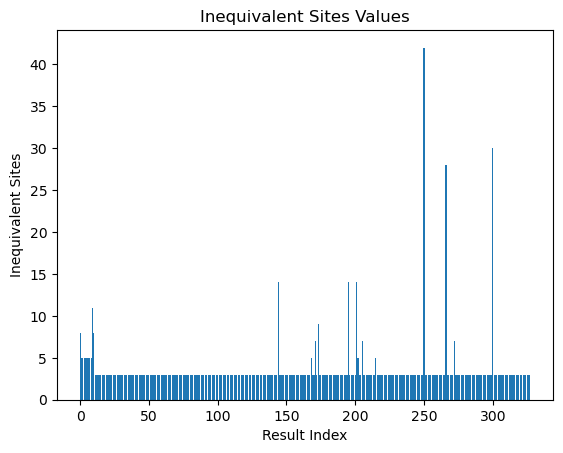

In [5]:
import matplotlib.pyplot as plt

# 提取 'inequivalent_sites' 值
inequivalent_sites_values = [result['inequivalent_sites'] for result in all_results]

# 创建柱状图
plt.bar(range(len(inequivalent_sites_values)), inequivalent_sites_values)

# 添加标题和标签
plt.title('Inequivalent Sites Values')
plt.xlabel('Result Index')
plt.ylabel('Inequivalent Sites')

# 显示图形
plt.show()

In [4]:
all_results[0]

{'cif_file': 'mp-578931.cif',
 'inequivalent_sites': 8,
 'CE': C_Atomic number start counting left top, left-right sequence      20.510264
 C_Atomic weight                                                   37.346485
 C_Boiling temperature                                           1110.598766
 C_Compression modulus                                              0.431634
 C_Density                                                       4594.464743
                                                                    ...     
 E_Radii covalent                                                  89.565114
 E_Radii metal (Waber)                                              1.079061
 E_Radii pseudo-potential (Zunger)                                  1.132212
 E_Valence electron number                                          7.909416
 E_Volume of atom (Villars, Daams)                                  1.603511
 Name: 0, Length: 74, dtype: float64,
 'motif_features': {'Q2_weighted_mean': 1.0,
  'Q2_we

In [13]:
import numpy as np

def safe_dict_to_vector(x):
    """
    安全地将数值特征转换为向量：
    - 如果是 dict → 提取数值型字段
    - 如果是 list → 尝试展开里面的 dict（取第一个）
    - 其他类型 → 忽略
    """
    vec = []
    
    if isinstance(x, dict):
        for k, v in x.items():
            if isinstance(v, (int, float, np.integer, np.floating)):
                vec.append(float(v))
    elif isinstance(x, list):
        # 尝试处理 list 中的 dict
        for item in x:
            if isinstance(item, dict):
                vec.extend(safe_dict_to_vector(item))
    return np.array(vec, dtype=float)

# 应用到所有 CIF
motif_vectors = [safe_dict_to_vector(r['motif_features']) for r in all_results]
connectivity_vectors = [safe_dict_to_vector(r['connectivity']) for r in all_results]
arrangement_vectors = [safe_dict_to_vector(r['arrangement']) for r in all_results]

In [14]:
CE = [res['CE'] for res in all_results]

In [15]:
print(CE[1].shape)
print(motif_vectors[1].shape)
print(connectivity_vectors[1].shape)
print(arrangement_vectors[1].shape)

(74,)
(80,)
(25,)
(7,)


In [11]:
arrangement_vectors[1]

array([ 32.05565189,  32.05565189,  32.05565189,   0.        ,
         2.22427352,  49.63072931, 139.5847986 ])

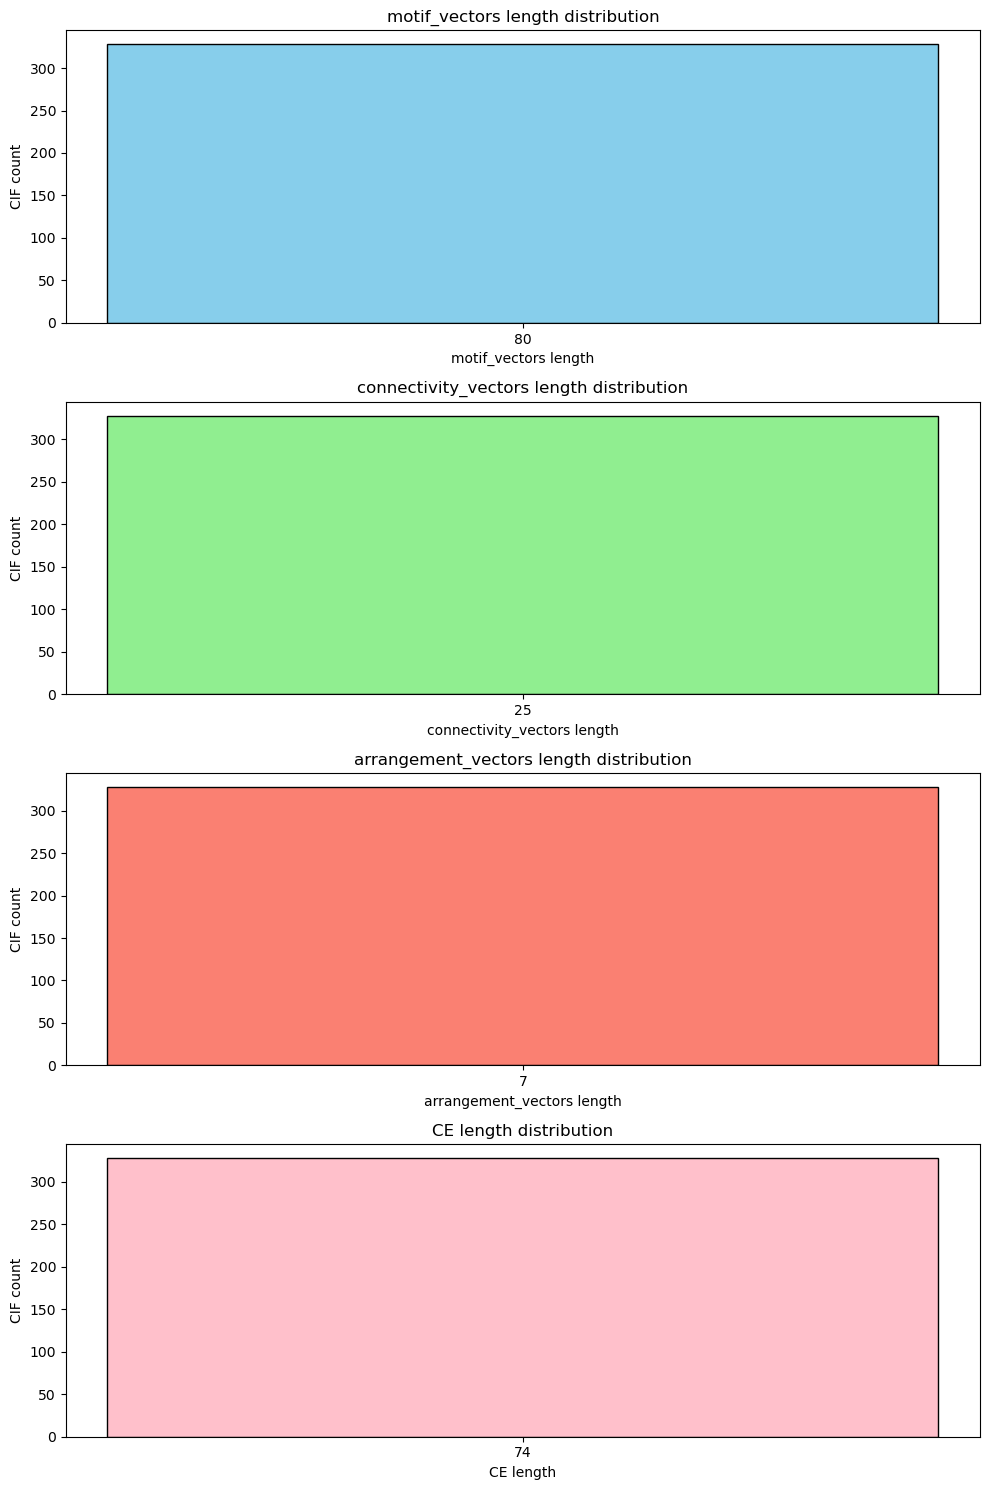

In [9]:
import collections
CE_lengths = [int(len(v)) for v in CE]
motif_vector_lengths = [int(len(v)) for v in motif_vectors]
connectivity_vector_lengths = [int(len(v)) for v in connectivity_vectors]
arrangement_vector_lengths = [int(len(v)) for v in arrangement_vectors]

# 统计每个长度的出现次数
CE_length_counter = collections.Counter(CE_lengths)
motif_length_counter = collections.Counter(motif_vector_lengths)
connectivity_length_counter = collections.Counter(connectivity_vector_lengths)
arrangement_length_counter = collections.Counter(arrangement_vector_lengths)

# 创建条形图
fig, axs = plt.subplots(4, 1, figsize=(10, 15))

# 绘制 motif_vectors 长度分布
axs[0].bar(motif_length_counter.keys(), motif_length_counter.values(), color='skyblue', edgecolor='black')
axs[0].set_xlabel("motif_vectors length")
axs[0].set_ylabel("CIF count")
axs[0].set_title("motif_vectors length distribution")
axs[0].set_xticks(list(motif_length_counter.keys()))

# 绘制 connectivity_vectors 长度分布
axs[1].bar(connectivity_length_counter.keys(), connectivity_length_counter.values(), color='lightgreen', edgecolor='black')
axs[1].set_xlabel("connectivity_vectors length")
axs[1].set_ylabel("CIF count")
axs[1].set_title("connectivity_vectors length distribution")
axs[1].set_xticks(list(connectivity_length_counter.keys()))

# 绘制 arrangement_vectors 长度分布
axs[2].bar(arrangement_length_counter.keys(), arrangement_length_counter.values(), color='salmon', edgecolor='black')
axs[2].set_xlabel("arrangement_vectors length")
axs[2].set_ylabel("CIF count")
axs[2].set_title("arrangement_vectors length distribution")
axs[2].set_xticks(list(arrangement_length_counter.keys()))

axs[3].bar(CE_length_counter.keys(), CE_length_counter.values(), color='pink', edgecolor='black')
axs[3].set_xlabel("CE length")
axs[3].set_ylabel("CIF count")
axs[3].set_title("CE length distribution")
axs[3].set_xticks(list(CE_length_counter.keys()))
# 调整子图间距
plt.tight_layout()

# 显示图形
plt.show()